In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from rich.progress import Progress
from rich.console import Console
import sys
import datetime



In [2]:
gaming = pd.read_csv('data/populargames.csv')

gaming.info()

gaming.drop(columns=['Unnamed: 0'], inplace=True)

gaming.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


In [3]:
#change 'release_date' to datetime 

gaming['Release Date'] = pd.to_datetime(gaming['Release Date'], errors='coerce')

gaming.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              1512 non-null   object        
 1   Release Date       1509 non-null   datetime64[ns]
 2   Team               1511 non-null   object        
 3   Rating             1499 non-null   float64       
 4   Times Listed       1512 non-null   object        
 5   Number of Reviews  1512 non-null   object        
 6   Genres             1512 non-null   object        
 7   Summary            1511 non-null   object        
 8   Reviews            1512 non-null   object        
 9   Plays              1512 non-null   object        
 10  Playing            1512 non-null   object        
 11  Backlogs           1512 non-null   object        
 12  Wishlist           1512 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(11)
memory usage: 153.

In [4]:
#change null to mean value doe rating column
#gaming['Rating'] = gaming['Rating'].fill(mean())
gaming['Rating'] = gaming['Rating'].fillna(gaming['Rating'].mean())
gaming['Release Date'] = gaming['Release Date'].fillna(datetime.datetime.now())

average rating of games over the years to understand trends in game quality.

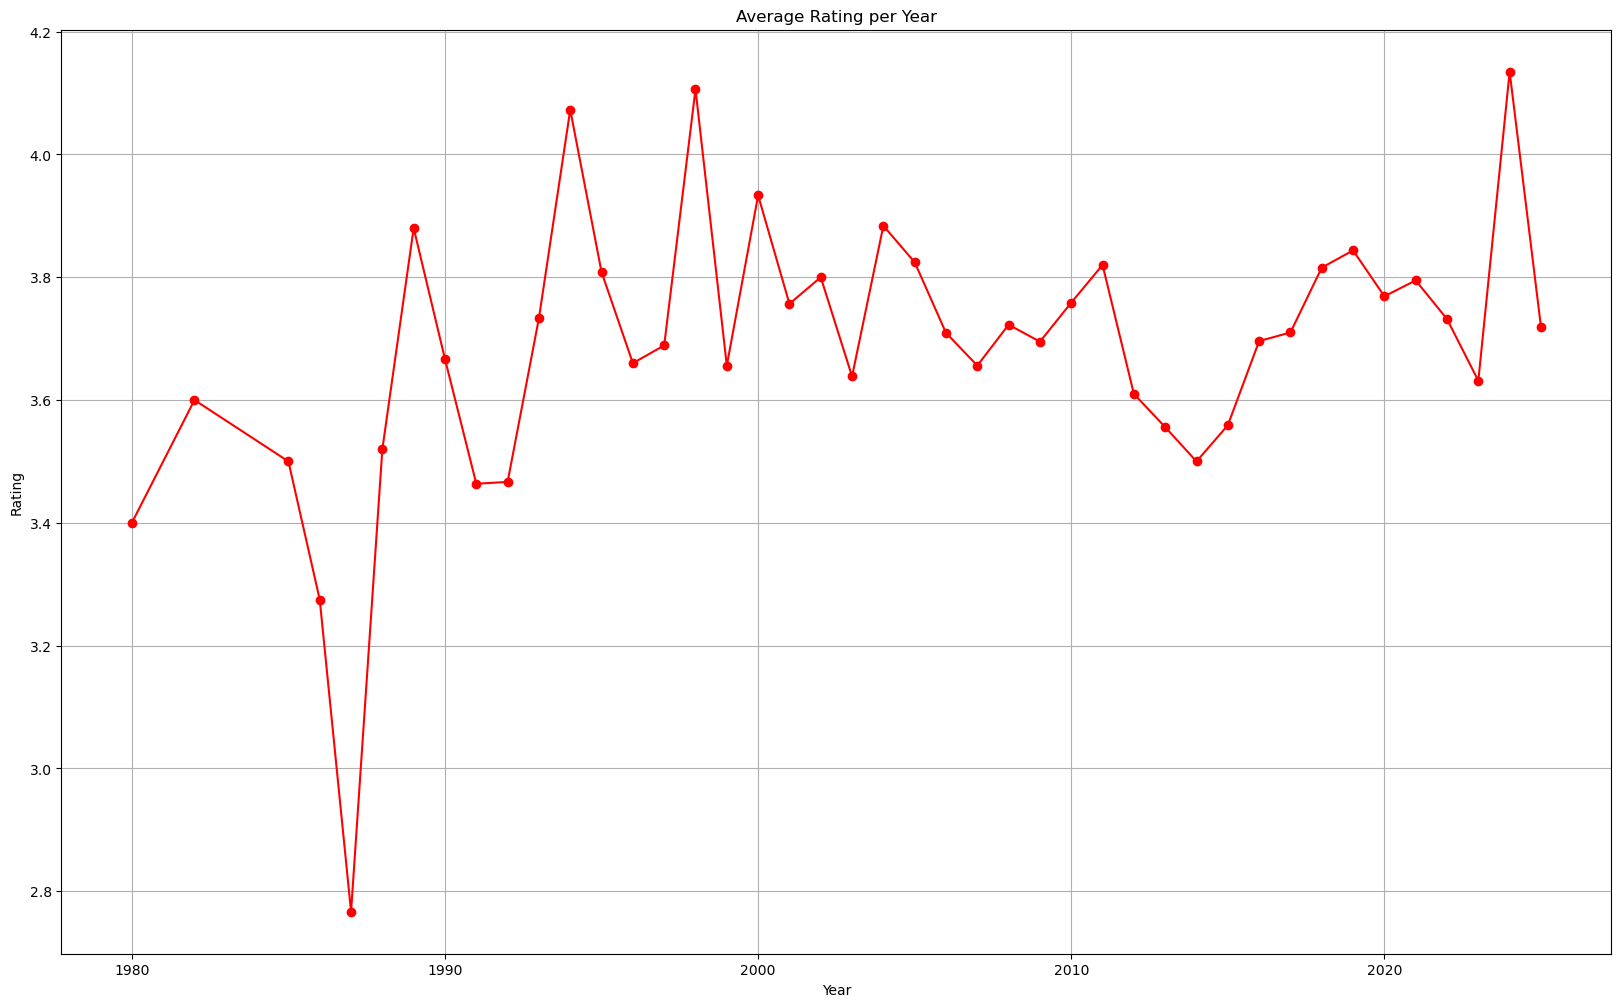

In [5]:

gaming['Year'] = gaming['Release Date'].dt.year
ratings_per_year = gaming.groupby('Year')['Rating'].mean()  

plt.figure(figsize=(20,12))
plt.plot(ratings_per_year.index, ratings_per_year.values, marker='o', color='r')
plt.title('Average Rating per Year')
plt.xlabel('Year')
plt.ylabel('Rating')
plt.grid()
plt.show()





using k-NN to find similar games based on numerical features like Rating, Plays, and Wishlist.


In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

#selecting numeric values for clustering
features = gaming[['Rating','Plays','Wishlist']].apply(pd.to_numeric, errors = 'coerce')  #convert to numeric

features = features.fillna(features.mean())


#normliize the data
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)  

#train knn model

knn = NearestNeighbors(n_neighbors=20, metric='euclidean', algorithm='auto').fit(scaled_features)    #5 nearest neighbors
game_index = 17 # red dead redemption 2 
distances, indices = knn.kneighbors([scaled_features[game_index]])  #get the 5 nearest neighbors of the game at index 17

#display the 5 nearest neighbors

print(f"game:{gaming.iloc[game_index]['Title']}")  #display the game name
print('similar games')
for idx in indices[0]:
    print(f"- {gaming.iloc[idx]['Title']} (rating: {gaming.iloc[idx]['Rating']})")    
   




game:Red Dead Redemption 2
similar games
- The Legend of Zelda: Breath of the Wild (rating: 4.4)
- Ghost Trick: Phantom Detective (rating: 4.4)
- Paper Mario: The Thousand-Year Door (rating: 4.4)
- The Legend of Zelda: Breath of the Wild (rating: 4.4)
- The Last of Us Part I (rating: 4.4)
- The House in Fata Morgana (rating: 4.4)
- The Legend of Zelda: Majora's Mask (rating: 4.4)
- 13 Sentinels: Aegis Rim (rating: 4.4)
- Metal Gear Solid 2: Sons of Liberty (rating: 4.4)
- Final Fantasy VI (rating: 4.4)
- Xenoblade Chronicles 3 (rating: 4.4)
- Persona 5 Royal (rating: 4.4)
- Yakuza 0 (rating: 4.4)
- Sekiro: Shadows Die Twice (rating: 4.4)
- Hollow Knight (rating: 4.4)
- Red Dead Redemption 2 (rating: 4.4)
- Portal 2 (rating: 4.4)
- Castlevania: Symphony of the Night (rating: 4.4)
- Shadow of the Colossus (rating: 4.4)
- God of War Ragnarök (rating: 4.4)


Cluster
0    701
1    211
2    277
3    277
4     46
dtype: int64


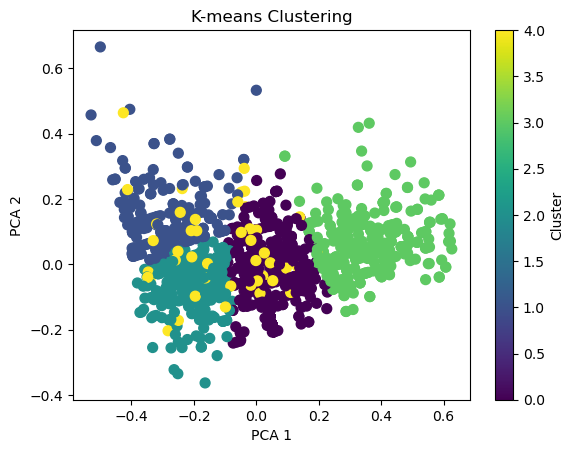

In [7]:
#Clusters games into groups based on numerical features using k-means clustering. Visualizes clusters in 2D space using PCA.

"""
points to note
- each color represents a cluster(game), same color means same characristics of games ( rating, plays, wishlist)
- each point represents a game. points in the same cluster are similar to each other
- what does this tell us ? 
- shows that how games are clustered based on their similarities
- tight clusters games are very similar 
- yellow color shows games that have moderate ratings but high number of plays 
"""

features = gaming[['Rating','Plays','Wishlist']].apply(pd.to_numeric, errors = 'coerce')  #convert to numeric
scaled_features = scaler.fit_transform(features.fillna(features.mean()))  #normalize the data

kmeans = KMeans(n_clusters=5, random_state=0).fit(scaled_features)  
gaming['Cluster'] = kmeans.labels_  #add cluster column to the dataframe

print(gaming.groupby('Cluster').size())  #display number of games in each cluster

from sklearn.decomposition import PCA   

pca = PCA(n_components=2)  #reduce to 2 dimensions
reduced_features = pca.fit_transform(scaled_features)  #fit and transform the data  
plt.scatter(reduced_features[:,0], reduced_features[:,1], c=kmeans.labels_, cmap='viridis', s=50)  #scatter plot
plt.title('K-means Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show() 

#gaming.groupby('Cluster')[['Rating', 'Plays', 'Wishlist']].mean()





In [8]:
#Extracts topics from game summaries using Latent Dirichlet Allocation (LDA) to uncover thematic groupings.

"""
     Topic 1: This topic focuses on gameplay exploration, adventure, and iconic games like Mario.
     Topic 2: This topic highlights story-driven games featuring characters like Sonic and themes like life, world-building, and player engagement.
     Topic 3: This topic is about games like the "Metal Gear" series, emphasizing gameplay, video releases, and long-running franchises.
     Topic 4: This topic includes games like Pokémon and others with a strong focus on adventure and immersive experiences.
     Topic 5: This topic highlights character-driven games with battles, storytelling, and multiplayer elements.
"""

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#convert summaries into a document matrix
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
dtm = vectorizer.fit_transform(gaming['Summary'].dropna())

#perform lda 
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

for i, topic in enumerate(lda.components_):
     print(f"Topic {i + 1}:")
     print(" ".join([vectorizer.get_feature_names()[i] for i in topic.argsort()[-10:]]))  #display top 10 words in each topic

Topic 1:
open player explore adventure action players mario world new game
Topic 2:
sonic young time new life player world man story game
Topic 3:
new gear metal developed video gameplay released games series game
Topic 4:
white games adventure play black experience pokémon new world game
Topic 5:
features character story battle time players characters player game new


/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [12]:
import pyLDAvis
import pyLDAvis.sklearn

# Prepare the visualization
lda_visualization = pyLDAvis.sklearn.prepare(lda, dtm, vectorizer)

# Save the modified visualization
with open("lda_visualization_dark.html", "w") as f:
    f.write(pyLDAvis.prepared_data_to_html(lda_visualization))

# Replace the template section in the file with your dark theme CSS
with open("lda_visualization_dark.html", "r+") as f:
    content = f.read()
    f.seek(0)
    f.write(content.replace("<style>", "<style>" + open("dark_theme.html").read()))
    f.truncate()

# Open the saved file in a browser
import webbrowser
webbrowser.open("lda_visualization_dark.html")





/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


True